In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)

# plt.rcParams.update(
# {"text.usetex": True, "font.family": "Helvetica", "font.size": 8}
# )

plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 10,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]

OUT = "/home/kzeleznikar/IJS-F1/Koda/toymodels/plots/"

import EI.ei_original as ut
import EI.ei_open_loop as eol
import EI.ei_unified as eu


In [3]:
pa= {"nk": 15,
    "gap": 2.0,
    "ta": 1.0,
    "tb": -0.3,
    "v": 2.5,
    "n0": 1.0,
    "t": 0.1,}

In [4]:
b2 = eu.tb_2d(pa["nk"], pa["gap"], pa["ta"], pa["tb"])
b1 = eu.tb_1d(pa["nk"], pa["gap"], pa["ta"], pa["tb"])
bf = eu.free_1d(pa["nk"], 2.0, pa["gap"])
z = eu.reshape_mode(b2.ea, b2)

assert b2.k.shape == (pa["nk"] ** 2, 2)
assert z.shape == (pa["nk"], pa["nk"])
assert np.isclose(np.sum(b2.w), 1.0)
assert b1.dim == bf.dim == 1
print("2D grid:", b2.shape, "modes:", b2.size)
print("1D:", b1.size, bf.size)

z

2D grid: (15, 15) modes: 225
1D: 15 15


array([[ 5.00000000e+00,  4.82709092e+00,  4.33826121e+00,
         3.61803399e+00,  2.79094307e+00,  2.00000000e+00,
         1.38196601e+00,  1.04370480e+00,  1.04370480e+00,
         1.38196601e+00,  2.00000000e+00,  2.79094307e+00,
         3.61803399e+00,  4.33826121e+00,  4.82709092e+00],
       [ 4.82709092e+00,  4.65418183e+00,  4.16535213e+00,
         3.44512490e+00,  2.61803399e+00,  1.82709092e+00,
         1.20905693e+00,  8.70795714e-01,  8.70795714e-01,
         1.20905693e+00,  1.82709092e+00,  2.61803399e+00,
         3.44512490e+00,  4.16535213e+00,  4.65418183e+00],
       [ 4.33826121e+00,  4.16535213e+00,  3.67652243e+00,
         2.95629520e+00,  2.12920429e+00,  1.33826121e+00,
         7.20227224e-01,  3.81966011e-01,  3.81966011e-01,
         7.20227224e-01,  1.33826121e+00,  2.12920429e+00,
         2.95629520e+00,  3.67652243e+00,  4.16535213e+00],
       [ 3.61803399e+00,  3.44512490e+00,  2.95629520e+00,
         2.23606798e+00,  1.40897706e+00,  6.18033989

findfont: Failed to find font weight normal, now using 300.


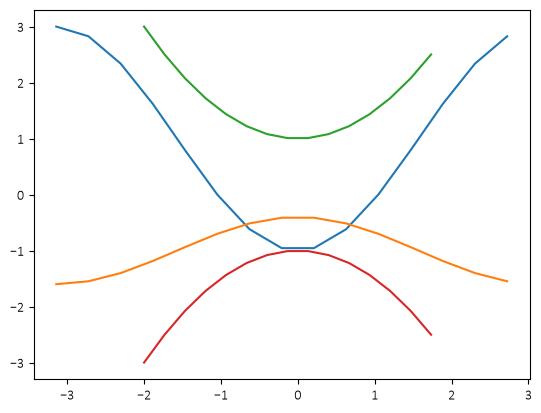

In [ ]:
plt.plot(b1.k, b1.ea)
plt.plot(b1.k, b1.eb)
plt.plot(bf.k, bf.ea)
plt.plot(bf.k, bf.eb)

In [6]:
kx = eu.reshape_mode(b2.k[:, 0], b2)
ky = eu.reshape_mode(b2.k[:, 1], b2)

ea2 = eu.reshape_mode(b2.ea, b2)
eb2 = eu.reshape_mode(b2.eb, b2)

findfont: Failed to find font weight normal, now using 300.


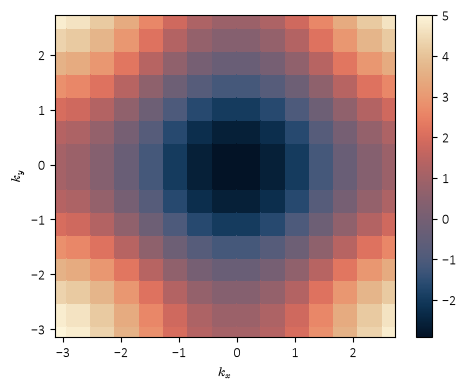

In [7]:
h = 0.8
fig, ax = plt.subplots(figsize=(5, h * 5))

im = ax.pcolormesh(
    kx,
    ky,
    ea2,
    shading="auto",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())

plt.tight_layout()

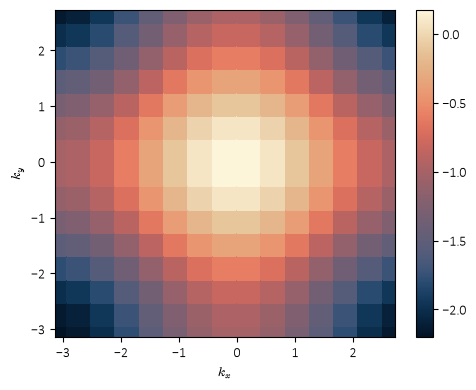

In [8]:
h = 0.8
fig, ax = plt.subplots(figsize=(5, h * 5))

im = ax.pcolormesh(
    kx,
    ky,
    eb2,
    shading="auto",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())

plt.tight_layout()

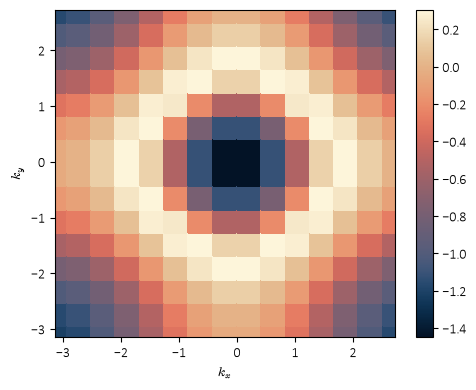

In [9]:
p = eu.MFPars(pa["v"], pa["n0"]) #dataclass za V, n_a+n_b in U_H
p.h #vrne v=uh, če uh==None, sicer uh

st = eu.mf_state(b2, p, d=0.3, m=-0.2) # diagonalizira MF hamiltonko, vzame band, V, n0, delta in m
eu.reshape_mode(st.e, b2) #diagonalizirana hamiltonka, [0] je sponji pas, [1] zgornji, reshaped nazaj (deflattened)

h = 0.8
fig, ax = plt.subplots(figsize=(5, h * 5))

im = ax.pcolormesh(
    kx,
    ky,
    eu.reshape_mode(st.e, b2)[1],
    shading="auto",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())

plt.tight_layout()

FD kemijski potencial:   0%|          | 0/120 [00:00<?, ?it/s]

0.5862657327320526
(15, 15)


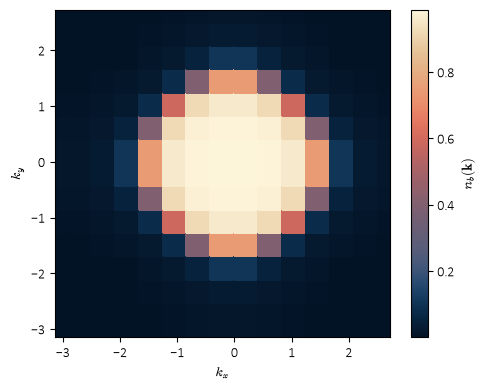

In [10]:
fs = eu.fermi(st, pa["t"], prog=True) #izracuna mu, iz ∑​wk​[f(Eαk​−μ)+f(Eβk​−μ)]=n0​, n0 dobi iz MFState
print(fs.mu)


na, nb = eu.band_occ(st, fs.n) #transformira v n_a in n_b (original bazo)

na = eu.reshape_mode(na, st.bd) #reshae v 2d grid

h = 0.8
fig, ax = plt.subplots(figsize=(5, h * 5))

im = ax.pcolormesh(
    kx,
    ky,
    na,
    shading="auto",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$n_b(\mathbf{k})$", rotation=90, labelpad=5)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())

plt.tight_layout()
print(na.shape) #na(k)

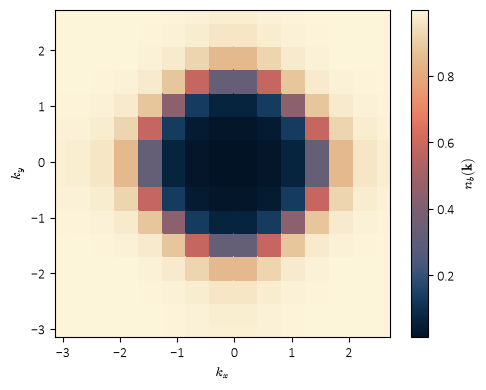

In [11]:
nb = eu.reshape_mode(nb, st.bd) #reshae v 2d grid

h = 0.8
fig, ax = plt.subplots(figsize=(5, h * 5))

im = ax.pcolormesh(
    kx,
    ky,
    nb,
    shading="auto",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$n_b(\mathbf{k})$", rotation=90, labelpad=5)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())

plt.tight_layout()

In [12]:
tg = eu.targets(st, fs.n) #vzame MFState in n_alpha, beta
tg #vrne delta, n_a-n_b, n0, n_a, n_b

Targets(d=0.375367134204439, m=-0.5959612003224145, n=0.999999999999996, na=0.2020193998387908, nb=0.7979806001612053)

test tokovi

In [13]:
ga = eu.gam_db(pa["t"], kap=0.3, wc=5.0, orb=None)
r = ga(st, fs.n)
h = 0.8
from matplotlib.colors import LogNorm

rp = r[r > 0.0]

norm = LogNorm(
    vmin=np.percentile(rp, 1),
    vmax=rp.max(),
)

In [14]:
p0 = np.argmin(np.sum(st.bd.k**2, axis=1))

# beta,p0 to alpha,k
rk = eu.reshape_mode(r[0, :, 1, p0], st.bd)

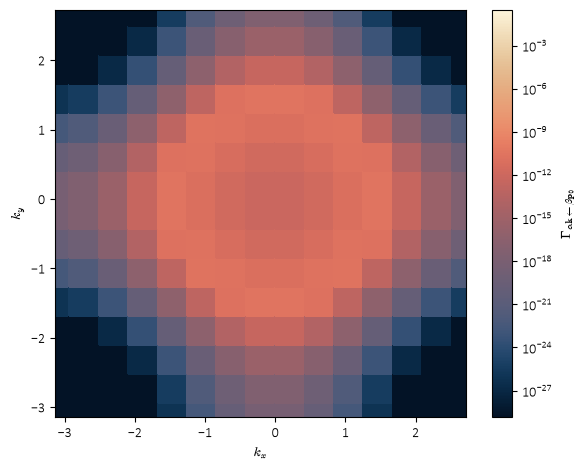

In [15]:
h = 0.8
fig, ax = plt.subplots(figsize=(6, h * 6))

im = ax.pcolormesh(
    kx,
    ky,
    rk,
    shading="auto",
    cmap=cmaps.lipari,
    norm=norm
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    r"$\Gamma_{\alpha\mathbf{k}\leftarrow\beta\mathbf{p}_0}$",
    rotation=90,
    labelpad=5,
)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())

plt.tight_layout()

toy model 1d tight binding, custom trnasition rates

In [16]:
db = eu.check_db(r, st, pa["t"]) #preveri detailed balance residual
db
dn = eu.dense_current(fs.n, r, st) #poracuna \dot(n_k), shape [2, nk**2]
print(r.shape)
print(dn.shape)
nr = eu.number_rate(dn, st.bd) # poracuna celoten current, sesteto po k, weights w_k
print(nr)


#toy rates, 0 za a==b in k==q, ostali transitioni kosntantni
rs = eu.gam_scalar(
    lambda a, k, b, q, s, n: 0.0 if (a == b and k == q) else 0.01
)
bt = eu.tb_1d(nk=30, gap=0.1, ta=1.0, tb=-0.3) #1d tight binding toy primer
pt = eu.MFPars(1.0)
stt = eu.mf_state(bt, pt, 0.1, 0.0)
nt = eu.fermi(stt, 0.2).n
rt = rs(stt, nt)

(2, 225, 2, 225)
(2, 225)
-6.295065530420981e-20


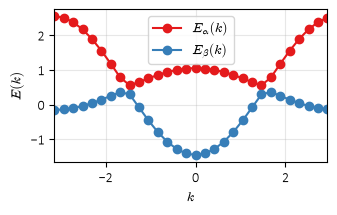

In [17]:
k = bt.k[:, 0]
ix = np.argsort(k)

h = 0.65
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(
    k[ix],
    stt.e[0, ix],
    color=set1_list[0],
    marker="o",
    label=r"$E_\alpha(k)$",
)

ax.plot(
    k[ix],
    stt.e[1, ix],
    color=set1_list[1],
    marker="o",
    label=r"$E_\beta(k)$",
)

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$E(k)$")
ax.set_xlim(k[ix][0], k[ix][-1])
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

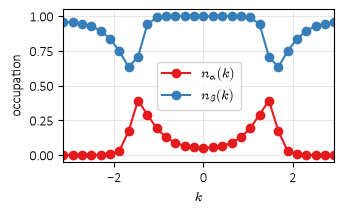

In [18]:
h = 0.65
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(
    k[ix],
    nt[0, ix],
    color=set1_list[0],
    marker="o",
    label=r"$n_\alpha(k)$",
)

ax.plot(
    k[ix],
    nt[1, ix],
    color=set1_list[1],
    marker="o",
    label=r"$n_\beta(k)$",
)

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"occupation")
ax.set_xlim(k[ix][0], k[ix][-1])
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

In [19]:
dn = eu.dense_current(nt, rt, stt)

print("Number rate:", eu.number_rate(dn, bt))
print("Detailed-balance error:", eu.check_db(rt, stt, 0.2))

Number rate: 8.029872339970767e-19
Detailed-balance error: 20.038461287332662


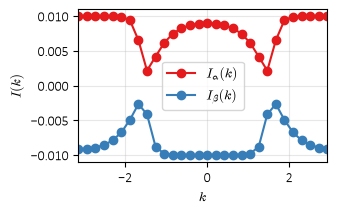

In [20]:
h = 0.65
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(
    k[ix],
    dn[0, ix],
    color=set1_list[0],
    marker="o",
    label=r"$I_\alpha(k)$",
)

ax.plot(
    k[ix],
    dn[1, ix],
    color=set1_list[1],
    marker="o",
    label=r"$I_\beta(k)$",
)

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$I(k)$")
ax.set_xlim(k[ix][0], k[ix][-1])
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

In [21]:
h = eu.lim_step(np.array([[0.9]]), np.array([[1.0]]), 1.0) #omeji korak, da ostane n_k <= 1
print(h)

0.07999999999999999


check za stacionarne/no bath pogoje, fazni prehod, Tc

In [22]:
sn = eu.solve_normal(b2, p, pa["t"], prog=True)  #resi za primer delta=0, fiksirano. 
print("Normal m:", sn.m, "Normal mu:", sn.mu, "Normal st:", sn.st.bd.shape)

la, _ = eu.pair_lambda(b2, p, pa["t"], m=sn.m)  #preveri, ce je normal state stabilen $\Delta = \lambda \Delta_\text{old}$, ce lam>1 nestabilen, lam <0 ni EI faza, lam=1: fazni prehod
print("lambda_lin:", la)

tc = eu.critical_temperature(b2, p, tlo=0.01, thi=2.0, tol=1.0e-6, nmax=50, prog=True) #najde Tc iz pogoja lam=1, bisekcija
print(tc)

se = eu.solve_eq(b2, p, t=pa["t"], d=0.01, m=0.0, mix=(0.2, 0.2), tol=1.0e-11, nmax=10000, chk=20, prog=True)#poracuna ravnovesni OP, m, mu pri dani temperaturi
print("ravnovesni Delta, m, mu:", se.d, se.m, se.mu)

Normal state:   0%|          | 0/10000 [00:00<?, ?it/s]

Normal m: -0.8661613738659744 Normal mu: 0.14513857081734266 Normal st: (15, 15)
lambda_lin: 1.1157094603541442


kriticna temp bisekcija:   0%|          | 0/50 [00:00<?, ?it/s]

0.1471306681632995


Equilibrium EI:   0%|          | 0/10000 [00:00<?, ?it/s]

ravnovesni Delta, m, mu: 0.2670714920288265 -0.8464032431976055 0.16123264561963874


In [23]:
di = 0.1 * se.d #init delta, stran od ravnoovesja
mi = np.clip(se.m + 0.2, -0.99, 0.99) #init m
si = eu.mf_state(b2, p, di, mi) #init state iz ravnovesnega, diag hamiltonka, u, v ...
ni = eu.fermi(si, 1.5 * pa["t"]).n #init n_k

d1 = eu.Dissipator(
    eu.gam_db(pa["t"], kap=0.3, wc=5.0),
    name="bath 1",
)
d2 = eu.Dissipator(
    eu.gam_db(pa["t"], kap=0.3, wc=5.0),
    name="bath 2",
)
dn = eu.total_current((d1, d2), si, ni) #intintial current shape (2, nk**2)
print(dn.shape)
so = eu.solve_open(b2, p, ni, (d1, d2), d=di, m=mi, dt=0.8, td=0.3, tm=0.3, tol=1.0e-7, nmax=10000, chk=10, prog=True)

nf = eu.fermi(so.st, pa["t"]).n  #poracuna fermi za prarametre open hamiltonke, to check ce je isto

print("Delta kopeli (ista t), m:", so.d, so.m)
print("FD max odstpanje:", np.max(np.abs(so.n - nf)))
print("err:", so.err)

(2, 225)


Open EI:   0%|          | 0/10000 [00:00<?, ?it/s]

Delta kopeli (ista t), m: 0.2670639270825842 -0.8464040864784433
FD max odstpanje: 9.83429327235108e-06
err: 9.541139029062631e-08


occupations check za bath pri isti temp.

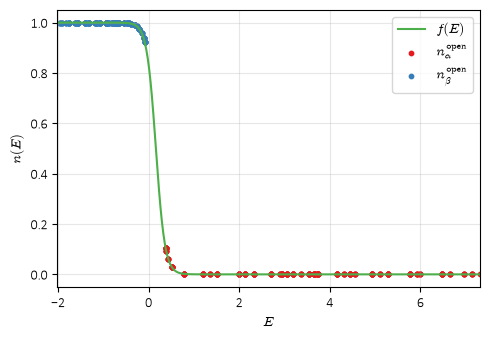

In [24]:
ea = so.st.e[0]
eb = so.st.e[1]


x = np.linspace(so.st.e.min(), so.st.e.max(), 300)
f = 1.0 / (np.exp(np.clip((x - eu.fermi(so.st, pa["t"]).mu) / pa["t"], -700.0, 700.0)) + 1.0)


h = 0.7
fig, ax = plt.subplots(figsize=(5, h * 5))
ax.plot(x, f, color=set1_list[2], label=r"$f(E)$")

ax.scatter(
    ea, so.n[0],
    s=10,
    color=set1_list[0],
    label=r"$n_\alpha^{\rm open}$",
)
ax.scatter(
    eb, so.n[1],
    s=10,
    color=set1_list[1],
    label=r"$n_\beta^{\rm open}$",
)

ax.set_xlabel(r"$E$")
ax.set_ylabel(r"$n(E)$")
ax.set_xlim(so.st.e.min(), so.st.e.max())
ax.grid(alpha=0.3)

ax.legend(
)

plt.tight_layout()

In [25]:
na, nb = eu.band_occ(so.st, so.n) #rotirano nazaj v n_a in n_b, shape (2, nk**2)


na2 = eu.reshape_mode(na, so.st.bd) #reshaped
nb2 = eu.reshape_mode(nb, so.st.bd)

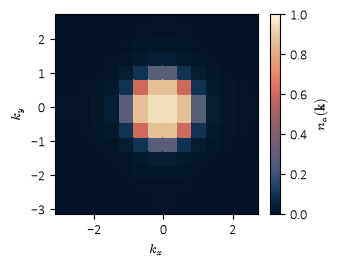

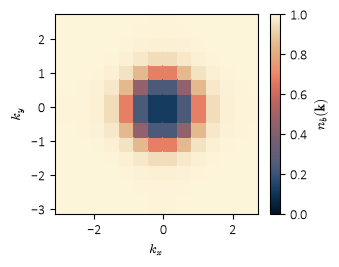

In [26]:
def plot_occ(kx, ky, n, cl):
    h = 0.8
    fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

    im = ax.pcolormesh(
        kx,
        ky,
        n,
        shading="auto",
        cmap=cmaps.lipari,
        vmin=0.0,
        vmax=1.0,
    )
    im.set_edgecolor("face")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cl, rotation=90, labelpad=5)

    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_xlim(kx.min(), kx.max())
    ax.set_ylim(ky.min(), ky.max())

    plt.tight_layout()
plot_occ(kx, ky, na2, r"$n_a(\mathbf{k})$")
plot_occ(kx, ky, nb2, r"$n_b(\mathbf{k})$")

konevrgenca check

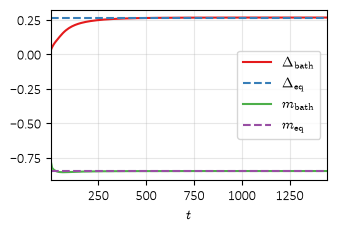

In [27]:
z = so.hist
x = z["t"]
h = 0.7

fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))
ax.plot(x, z["d"], color=set1_list[0], label=r"$\Delta_{\rm bath}$")
ax.plot(x, np.full_like(x, se.d), "--", color=set1_list[1],
        label=r"$\Delta_{\rm eq}$")
ax.plot(x, z["m"], color=set1_list[2], label=r"$m_{\rm bath}$")
ax.plot(x, np.full_like(x, se.m), "--", color=set1_list[3],
        label=r"$m_{\rm eq}$")
ax.set_xlabel(r"$t$")
ax.set_xlim(x[0], x[-1])
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

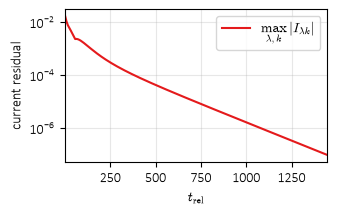

In [28]:
ii = np.maximum(z["cur"], 1.0e-16)

h = 0.65
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.semilogy(
    x,
    ii,
    color=set1_list[0],
    label=r"$\max_{\lambda,k}|I_{\lambda k}|$",
)

ax.set_xlabel(r"$t_{\rm rel}$")
ax.set_ylabel(r"current residual")
ax.set_xlim(x[0], x[-1])
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

primerjava metod

In [ ]:
bd = ut.sq(pa["nk"], pa["gap"], pa["ta"], pa["tb"])
p = ut.Pars(v=pa["v"], t=pa["t"], n=pa["n0"], uh=None)
sr = ut.solve(bd, p, y0=(se.d, se.m, se.mu), tol=1.0e-10, nmax=3000)

ed = abs(se.d - sr.d)
em = abs(se.m - sr.m)
eu0 = abs(se.mu - sr.mu)
bd0 = abs(so.d - sr.d)
bm0 = abs(so.m - sr.m)

print("                     utils        unified       2kopeli")
print(f"Delta       {sr.d:14.10f} {se.d:14.10f} {so.d:14.10f}")
print(f"m           {sr.m:14.10f} {se.m:14.10f} {so.m:14.10f}")
print(f"Delta razlika  metod               {ed:10.3e} {bd0:14.3e}")
print(f"m razlika metod                     {em:10.3e} {bm0:14.3e}")

                     utils        unified       two baths
Delta         0.2670714921   0.2670714920   0.2670639271
m            -0.8464032432  -0.8464032432  -0.8464040865
Delta diff                  5.609e-11      7.565e-06
m diff                      9.854e-12      8.433e-07


disperzija, na trikotniku

In [30]:
def _seg(a, b, nq):
    z = np.linspace(0.0, 1.0, nq, endpoint=False)
    return a[None, :] + z[:, None] * (b - a)[None, :]

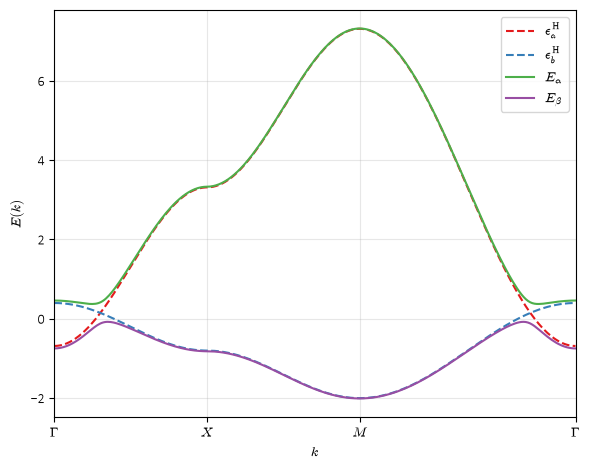

In [31]:
nq = 100
g = np.array([0.0, 0.0])
x = np.array([np.pi, 0.0])
m = np.array([np.pi, np.pi])
k = np.vstack((_seg(g, x, nq), _seg(x, m, nq),
                _seg(m, g, nq), g[None, :]))
s = np.concatenate(([0.0], np.cumsum(np.linalg.norm(np.diff(k, axis=0), axis=1)))) #dolzina po poti

c = np.cos(k[:, 0]) + np.cos(k[:, 1]) #bare disperzija za tb

ea = 0.5 * pa["gap"] - 2.0 * pa["ta"] * c
eb = -0.5 * pa["gap"] - 2.0 * pa["tb"] * c
na = 0.5 * (pa["n0"] + se.m)
nb = 0.5 * (pa["n0"] - se.m)
eah = ea + pa["v"] * nb
ebh = eb + pa["v"] * na
av = 0.5 * (eah + ebh)
xi = 0.5 * (eah - ebh)
ek = np.sqrt(xi * xi + se.d * se.d) #diagonaliziana disperzija

h = 0.8
fig, ax = plt.subplots(figsize=(6, h * 6))
ax.plot(s, eah, "--", color=set1_list[0], label=r"$\epsilon_a^{\rm H}$")
ax.plot(s, ebh, "--", color=set1_list[1], label=r"$\epsilon_b^{\rm H}$")
ax.plot(s, av + ek, color=set1_list[2], label=r"$E_\alpha$")
ax.plot(s, av - ek, color=set1_list[3], label=r"$E_\beta$")
ix = np.array([0, nq, 2 * nq, 3 * nq])
ax.set_xticks(s[ix])
ax.set_xticklabels([r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"])
ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$E(k)$")
ax.set_xlim(s[0], s[-1])
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

primerjava Delta, V scan za brez kopeli in 2 kopeli

In [32]:
nk = 16
ta = 1.0
tb = -0.3
gap = 1.0
t0 = 0.1
n0 = 1.0

b2 = eu.tb_2d(nk, gap, ta, tb)

va = np.linspace(0.01, 8.0, 41)

de = np.zeros_like(va)
do = np.zeros_like(va)
me = np.zeros_like(va)
mo = np.zeros_like(va)
er = np.zeros_like(va)
fe = np.zeros_like(va)

oke = np.zeros(va.size, dtype=bool)
oko = np.zeros(va.size, dtype=bool)


In [33]:
d0 = 0.1
m0 = 0.0

bar = tqdm(enumerate(va), total=va.size, desc="V scan")

for j, vv in bar:
    p = eu.MFPars(
        v=vv,
        n=n0,
        uh=None,
    )

    se = eu.solve_eq(
        b2,
        p,
        t=t0,
        d=max(abs(d0), 0.05),
        m=m0,
        mix=(0.15, 0.15),
        tol=1.0e-5,
        nmax=20000,
        chk=20,
        prog=False,
    )

    de[j] = abs(se.d)
    me[j] = se.m
    oke[j] = se.ok

    d0 = se.d
    m0 = se.m

    di = max(0.8 * abs(se.d), 1.0e-3)
    mi = np.clip(se.m + 0.02, -0.99, 0.99)

    si = eu.mf_state(b2, p, di, mi)
    ni = eu.fermi(si, 1.5 * t0).n

    d1 = eu.Dissipator(
        eu.gam_db(t0*0.5, kap=0.3, wc=6.0),
        name="bath 1",
    )

    d2 = eu.Dissipator(
        eu.gam_db(2*t0, kap=0.3, wc=6.0),
        name="bath 2",
    )

    so = eu.solve_open(
        b2,
        p,
        ni,
        (d1, d2),
        d=di,
        m=mi,
        dt=0.8,
        td=0.3,
        tm=0.3,
        tol=1.0e-5,
        nmax=20000,
        chk=10,
        prog=False,
    )

    nf = eu.fermi(so.st, t0).n

    do[j] = abs(so.d)
    mo[j] = so.m
    er[j] = so.err
    fe[j] = np.max(np.abs(so.n - nf))
    oko[j] = so.ok

    bar.set_postfix(
        v=f"{vv:.2f}",
        de=f"{de[j]:.3f}",
        do=f"{do[j]:.3f}",
    )

V scan: 100%|██████████| 41/41 [01:08<00:00,  1.68s/it, de=0.001, do=0.001, v=8.00]


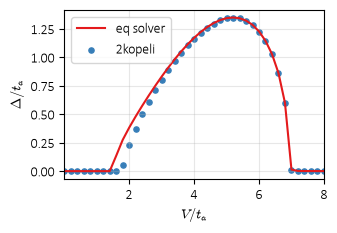

In [34]:
xv = va / ta

h = 0.7
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(
    xv,
    de / ta,
    color=set1_list[0],
    label=r"eq solver",
)

ax.scatter(
    xv,
    do / ta,
    s=14,
    color=set1_list[1],
    label=r"2kopeli",
)

ax.set_xlabel(r"$V/t_a$")
ax.set_ylabel(r"$\Delta/t_a$")
ax.set_xlim(xv[0], xv[-1])
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

In [35]:
nk = 15

b2 = eu.tb_2d(
    nk=nk,
    gap=1.0,
    ta=1.0,
    tb=-0.3,
)

p = eu.MFPars(
    v=5.0,
    n=1.0,
    uh=None,       # None means U_H = V
)

s0 = eu.solve_eq(
    b2, p,
    t=0.0,
    d=1.0,
    m=0.0,
    mix=(0.15, 0.15),
    tol=1.0e-10,
    nmax=20000,
    chk=20,
    prog=True,
)

d00 = abs(s0.d)

tc = eu.critical_temperature(
    b2, p,
    tlo=1.0e-4,
    thi=2.0,
    tol=1.0e-7,
    nmax=100,
    prog=True,
)

print("Delta_0 =", d00)
print("m_0     =", s0.m)
print("T_c     =", tc)

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

Delta_0 = 1.3438526517404992
m_0     = -0.7795440595901427
T_c     = 0.6195544337972998


In [36]:
nt = 20                 # use 15 or 21 for the final plot
tn = np.linspace(0.03, 1.5, nt)

t1a = tn * tc
t2a = tn * tc

kap = 0.3
wc = 5.0

da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
ok = np.zeros((nt, nt), dtype=bool)

deq = s0.d
meq = s0.m

for j in tqdm(range(nt), desc="T2 rows"):
    t2 = t2a[j]

    # Equilibrium solution at the diagonal point T1=T2=T2
    se = eu.solve_eq(
        b2, p,
        t=t2,
        d=max(abs(deq), 1.0e-6),
        m=meq,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    deq = se.d
    meq = se.m

    n = se.n.copy()
    d = se.d
    m = se.m

    for i in tqdm(range(j, nt), desc="T1 columns", leave=False):
        t1 = t1a[i]

        ds = (
            eu.Dissipator(
                eu.gam_db(t1, kap=kap, wc=wc),
                name="bath 1",
            ),
            eu.Dissipator(
                eu.gam_db(t2, kap=kap, wc=wc),
                name="bath 2",
            ),
        )

        so = eu.solve_open(
            b2, p,
            n,
            ds,
            d=d,
            m=m,
            dt=0.8,
            td=0.3,
            tm=0.3,
            tol=1.0e-4,
            nmax=20000,
            chk=10,
            prog=False,
        )

        # Warm start for the next T1 point in this row
        n = so.n.copy()
        d = so.d
        m = so.m

        da[j, i] = abs(so.d)
        ma[j, i] = so.m
        er[j, i] = so.err
        ok[j, i] = so.ok

        # Valid because both baths have identical coupling parameters
        da[i, j] = da[j, i]
        ma[i, j] = ma[j, i]
        er[i, j] = er[j, i]
        ok[i, j] = ok[j, i]

T2 rows: 100%|██████████| 20/20 [03:38<00:00, 10.91s/it]


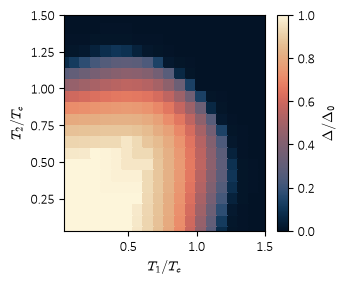

All converged: True
Largest residual: 9.999129559984388e-05


In [37]:
z = da / d00

h = 0.85
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

im = ax.pcolormesh(
    tn,
    tn,
    z,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
)
im.set_edgecolor("face")

cb = fig.colorbar(im, ax=ax)
cb.set_label(r"$\Delta/\Delta_0$", rotation=90, labelpad=5)

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$T_2/T_c$")
ax.set_xlim(tn.min(), tn.max())
ax.set_ylim(tn.min(), tn.max())

plt.tight_layout()
# plt.savefig("EI_V=5_G=1=tb2d_gapcmap.pdf")
plt.show()

print("All converged:", np.all(ok))
print("Largest residual:", np.nanmax(er))

1D model tb, primerjava distribucij

In [38]:
nk1 = 101

b1 = eu.tb_1d(
    nk=nk1,
    gap=0.1,
    ta=1.0,
    tb=-0.3,
)

p1 = eu.MFPars(
    v=5.0,
    n=1.0,
    uh=None,
)

s01 = eu.solve_eq(
    b1, p1,
    t=0.0,
    d=1.0,
    m=0.0,
    mix=(0.15, 0.15),
    tol=1.0e-10,
    nmax=20000,
    chk=20,
    prog=True,
)

d01 = abs(s01.d)

tc1 = eu.critical_temperature(
    b1, p1,
    tlo=1.0e-4,
    thi=2.0,
    tol=1.0e-7,
    nmax=100,
    prog=True,
)

print("Delta_0 =", d01)
print("T_c     =", tc1)

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

Delta_0 = 2.310319796642628
T_c     = 1.1325746885225179


In [39]:
r1 = 0.1
r2 = 2.0

t1 = r1 * tc1
t2 = r2 * tc1
tr = 0.5 * (t1 + t2)

se1 = eu.solve_eq(
    b1, p1,
    t=tr,
    d=s01.d,
    m=s01.m,
    mix=(0.15, 0.15),
    tol=1.0e-9,
    nmax=20000,
    chk=20,
    prog=True,
)

ds1 = (
    eu.Dissipator(
        eu.gam_db(t1, kap=0.3, wc=5.0),
        name="bath 1",
    ),
    eu.Dissipator(
        eu.gam_db(t2, kap=0.3, wc=5.0),
        name="bath 2",
    ),
)

so1 = eu.solve_open(
    b1, p1,
    se1.n,
    ds1,
    d=se1.d,
    m=se1.m,
    dt=0.8,
    td=0.3,
    tm=0.3,
    tol=1.0e-6,
    nmax=20000,
    chk=10,
    prog=True,
)

ff1 = eu.fermi(so1.st, tr)

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

Open EI:   0%|          | 0/20000 [00:00<?, ?it/s]

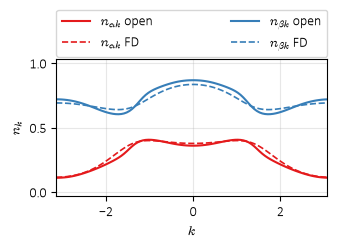

In [40]:
k = np.asarray(b1.k).squeeze()

ix = np.argsort(k)
k = k[ix]

h = 0.75
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(
    k, so1.n[0, ix],
    color=set1_list[0],
    lw=1.5,
    label=r"$n_{\alpha k}$ open",
)

ax.plot(
    k, ff1.n[0, ix],
    "--",
    color=set1_list[0],
    lw=1.2,
    label=r"$n_{\alpha k}$ FD",
)

ax.plot(
    k, so1.n[1, ix],
    color=set1_list[1],
    lw=1.5,
    label=r"$n_{\beta k}$ open",
)

ax.plot(
    k, ff1.n[1, ix],
    "--",
    color=set1_list[1],
    lw=1.2,
    label=r"$n_{\beta k}$ FD",
)

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$n_k$")
ax.set_xlim(k.min(), k.max())
ax.set_ylim(-0.03, 1.03)
ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=2,
)

plt.tight_layout()
# plt.savefig("1d_tb_particle_density_occ.pdf")
plt.show()